In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 

In [3]:
import json
import os
import time
from typing import Sequence, Tuple
import numpy as np
import jax
import jax.numpy as jnp
from jaxued.environments.underspecified_env import EnvParams, EnvState, UnderspecifiedEnv
from jaxued.utils import compute_max_mean_returns_epcount
import optax
from flax import struct
from flax.training.train_state import TrainState as BaseTrainState
import flax.linen as nn
from flax.linen.initializers import constant, orthogonal
import distrax
import orbax.checkpoint as ocp
import wandb
from jaxued.environments.maze.env_editor import LocalKeyMazeEditorRotateSplitAct
from jaxued.environments.maze.env_editor_sokoban import LocalSokobanMazeEditor, LocalSokobanMazeEditorRotate, LocalSokobanMazeEditorRotateSplitAct
from jaxued.linen import ResetRNN
from jaxued.environments import Maze, MazeRenderer, ObservedMazeRenderer, LocalObservedMazeRenderer, SokobanMaze
from jaxued.environments.maze import Level, ObservedLevel, make_level_generator, make_level_w_key_generator, make_level_sokoban_generator, make_level_mutator_minimax, make_level_mutator_minimax_key, make_level_mutator_minimax_sokoban
from jaxued.wrappers import AutoReplayWrapper
import chex

import logging
import hydra
from omegaconf import DictConfig, OmegaConf
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

In [4]:
from omegaconf import OmegaConf
from hydra import initialize, compose


def load_hydra_config(config_path, config_name):
    # Initialize the Hydra context
    with initialize(config_path=config_path):
        # Compose the configuration
        cfg = compose(config_name=config_name)
        return cfg
    
config_path = "config"  # path to the directory containing the config file
config_name = "main_obs_gen"  # name of the config file without the extension

config = load_hydra_config(config_path, config_name)

if config["num_env_steps"] is not None:
    config["num_updates"] = config["num_env_steps"] // (config["num_train_envs"] * config["num_steps"])

if config['mode'] == 'eval':
    os.environ['WANDB_MODE'] = 'disabled'
    

/tmp/ipykernel_1162469/3239372705.py:7: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path=config_path):


In [20]:
env = SokobanMaze(max_height=9, max_width=9, agent_view_size=5, normalize_obs=True, min_boxes=1)
sample_random_level = make_level_sokoban_generator(env.max_height, env.max_width, 15, 10)
mutate_level = make_level_mutator_minimax_sokoban(100)

# env = Maze(max_height=9, max_width=9, agent_view_size=5, normalize_obs=True)

env_renderer = MazeRenderer(env, tile_size=8, render_boxes=True)
env_params = env.default_params

# sample_random_level = make_level_generator(env.max_height, env.max_width, 15)
# mutate_level = make_level_mutator_minimax(100)

# sample_random_level = make_level_w_key_generator(env.max_height, env.max_width, 15)
# mutate_level = make_level_mutator_minimax_key(100)

def sample_empty_level():
    w, h = env._env.max_width, env._env.max_height
    return ObservedLevel(
        wall_map=jnp.zeros((h, w), dtype=jnp.bool_),
        box_map=jnp.zeros((h, w), dtype=jnp.bool_),
        box_goal_map=jnp.zeros((h, w), dtype=jnp.bool_),
        max_boxes=jnp.array(0, dtype=jnp.uint8),
        observation_map=jnp.zeros((h, w), dtype=jnp.bool_),
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=jnp.array([1, 1], dtype=jnp.uint32),
        agent_dir=jnp.array(0, dtype=jnp.uint8),
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

def sample_random_init_level(rng):
    w, h = env._env.max_width, env._env.max_height
    observation_map = jnp.zeros((h, w), dtype=jnp.bool_)
    rng_pos, rng_dir = jax.random.split(rng)
    agent_pos = jax.random.randint(rng_pos, (2,), 0, jnp.array([h, w]), dtype=jnp.uint32)
    agent_dir = jax.random.randint(rng_dir, (), 0, 4, dtype=jnp.uint8)
    return ObservedLevel(
        wall_map=jnp.zeros((h, w), dtype=jnp.bool_),
        box_map=jnp.zeros((h, w), dtype=jnp.bool_),
        box_goal_map=jnp.zeros((h, w), dtype=jnp.bool_),
        max_boxes=jnp.array(0, dtype=jnp.uint8),
        observation_map=observation_map.at[agent_pos[1], agent_pos[0]].set(True),
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=agent_pos,
        agent_dir=agent_dir,
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

def sample_test_level(rng):
    w, h = env._env.max_width, env._env.max_height
    observation_map = jnp.zeros((h, w), dtype=jnp.bool_)
    rng_pos, rng_dir = jax.random.split(rng)
    agent_pos = jax.random.randint(rng_pos, (2,), 0, jnp.array([h, w]), dtype=jnp.uint32)
    agent_dir = jax.random.randint(rng_dir, (), 1, 2, dtype=jnp.uint8)
    return ObservedLevel(
        wall_map=jnp.zeros((h, w), dtype=jnp.bool_),
        box_map=jnp.zeros((h, w), dtype=jnp.bool_).at[agent_pos[1]+1, agent_pos[0]].set(True),
        box_goal_map=jnp.zeros((h, w), dtype=jnp.bool_),
        max_boxes=jnp.array(config['max_boxes'], dtype=jnp.uint8),
        observation_map=jnp.ones((h, w), dtype=jnp.bool_),
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=agent_pos,
        agent_dir=agent_dir,
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

rng = jax.random.PRNGKey(14532)
rng, _rng = jax.random.split(rng)

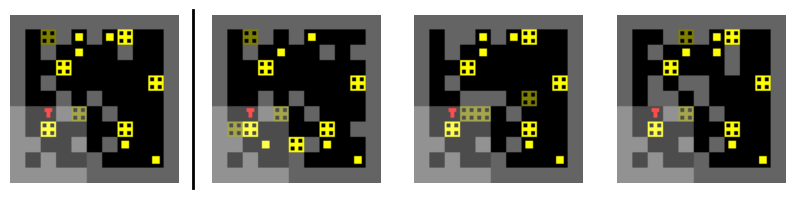

In [34]:
N_EDITS = 10
N_CHILDREN = 3

rng, rng_level, rng_mutate = jax.random.split(rng, 3)

example_level = sample_random_level(rng_level)
example_level_image = env_renderer.render_level(example_level, env_params)

child_levels = jax.vmap(mutate_level, in_axes=(0, None, None))(jax.random.split(rng_mutate, N_CHILDREN), example_level, N_EDITS)
child_level_images = jax.vmap(env_renderer.render_level, in_axes=(0, None))(child_levels, env_params)

fig, axes = plt.subplots(1, 1+N_CHILDREN, figsize=(10, 5))
axes[0].imshow(example_level_image)
axes[0].axis('off');

for ax, img in zip(axes.flatten()[1:], child_level_images):
    ax.imshow(img)
    ax.axis('off');

#fig.subplots_adjust(wspace=0.05)
x0 = axes[0].get_position().x1 +0.015
y0, y1 = axes[0].get_position().y0, axes[0].get_position().y1
fig.add_artist(plt.Line2D([x0, x0], [y0-0.01, y1+0.01], color='black', linewidth=2, transform=fig.transFigure))